Importing the Necessary Modules

In [24]:
import pandas as pd
from sqlalchemy import create_engine
from mpl_toolkits.mplot3d import axes3d
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import pyplot
import random
import json
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

Connecting to the Database

In [ ]:
db_username_0 = 'simulationuser'
db_password_0 = 'simulations2024'
db_host_0 = 'localhost'
db_port_0 = '5432'
db_name_0 = 'simulations_data'
table_name_0 = 'composite_data'

In [26]:
connection_string = f"postgresql://{db_username_0}:{db_password_0}@{db_host_0}:{db_port_0}/{db_name_0}"
engine = create_engine(connection_string)
query = f"SELECT * FROM {table_name_0}"
df = pd.read_sql(query, engine)

The DataFrame

In [27]:
df.head()

,id,eps,n_0_squared,psi_e,b_e,psi_plus,b_plus,u_list,r_list,k_e_psi_e_list,k_e_b_e_list,k_e_psi_plus_list,k_e_b_plus_list,heat_flux_psi_e_b_e_list,heat_flux_psi_e_b_plus_list,b_e_psi_plus_list,b_e_b_plus_list,psi_plus_b_plus_list,eta_list
0,1500,0.123943,318.864022,"[-0.011744609035812982, -0.011215305626181015,...","[-5.517162102724528, -3.1920707854231463, -0.9...","[-0.0016475367466768115, -0.002355776502265530...","[10.73076649947905, 10.77581128940965, 10.5402...","[0.4615413218450946, 0.4686702377764153, 0.478...","[0.6551578220909112, 0.8945764375320215, 1.175...","[0.00013793584140409996, 0.0001257830802886475...","[30.43907766773974, 10.189315899151941, 0.8663...","[2.7143773316504123e-06, 5.549682928626416e-06...","[115.14934966634185, 116.11810894496844, 111.0...","[0.06479691188370344, 0.035800049438924265, 0....","[-0.1260286571909809, -0.12085401698078094, -0...","[0.009089727301611367, 0.007519805349868124, 0...","[-59.203378264111755, -34.39715240615747, -9.8...","[-0.01767933212790023, -0.025385403028438877, ...","[[1.0369206541904592], [-1.6813054180526377], ..."
1,1501,0.123943,318.864022,"[-0.008147157474100065, -0.008292099833020762,...","[-0.832904729882089, 0.14071461474575664, 1.27...","[0.0006807256129005129, 0.0007313699095774325,...","[-0.7190970906032216, -0.6095182673572732, -0....","[0.23703131704960073, 0.23479400902756253, 0.2...","[-0.18778048603775238, -0.2053401462453807, -0...","[6.637617490778455e-05, 6.875891964078295e-05,...","[0.6937302890599556, 0.019800602803046713, 1.6...","[4.6338736005877887e-07, 5.349019446353018e-07...","[0.5171006257140178, 0.3715125182422124, 0.293...","[0.006785805995272157, -0.0011668196334368695,...","[0.005858597236311648, 0.005054186322976349, 0...","[-0.0005669795827367211, 0.0001029144350628272...","[0.5989393680078723, -0.0857681281716798, -0.6...","[-0.0004895078077358536, -0.000445783320082882...","[[1.418213787060706], [0.8827834628841255], [0..."
2,1502,0.123943,318.864022,"[-0.003781434990007615, -0.001308768972368787,...","[7.429632504232679, 7.616174400779771, 7.45893...","[0.0017201097552821953, 0.0016973192181066884,...","[0.26192796713213556, -0.016191321040263613, -...","[0.3398928494975913, 0.33847860008307173, 0.33...","[-0.22023434840890527, -0.0752140155360062, 0....","[1.4299250583653892e-05, 1.7128762230352505e-0...","[55.199439147950756, 58.00611250309311, 55.635...","[2.958777570216974e-06, 2.8808925281543e-06, 2...","[0.06860625996597308, 0.0002621588770288832, 0...","[-0.028094672314403355, -0.009967812743890003,...","[-0.000990463579775022, 2.1190698599158928e-05...","[0.012779783348692317, 0.012927079178895698, 0...","[1.9460285383725033, -0.12331592482166262, -2....","[0.00045054485144522063, -2.7481840368174608e-...","[[-0.6679438799496836], [-0.8041216677662598],..."
3,1503,0.123943,318.864022,"[-0.008102021680746106, -0.007577287179778589,...","[-13.405475487140006, -12.142974722866745, -10...","[-0.007065355563569785, -0.007211423776971252,...","[3.432058579711073, 2.9279736455346024, 2.4210...","[0.15021463519080008, 0.17082991418834997, 0.1...","[1.9382048681079675, 1.850150346137473, 2.4148...","[6.564275531527996e-05, 5.7415281004836965e-05...","[179.70677303631157, 147.4518351201807, 119.05...","[4.991924923966652e-05, 5.2004632891066315e-05...","[11.779026094568387, 8.573029668945189, 5.8616...","[0.10861145303751879, 0.09201080669195365, 0.1...","[-0.0278066130224098, -0.022186097167038923, -...","[0.09471445081536302, 0.08756813663964214, 0.0...","[-46.00837716074533, -35.55430996694667, -26.4...","[-0.024248714180659044, -0.021114858765753426,...","[[0.20668630436664126], [1.0343110874926529], ..."
4,1504,0.123943,318.864022,"[-0.0007052290130828054, -0.003475921446700475...","[7.188510348955567, 7.255315274332748, 7.40112...","[0.01155266108186768, 0.011468163968599393, 0....","[-0.9665805895951766, 0.23618988496103174, 1.4...","[0.1388431307750241, 0.13278906064134477, 0.12...","[-0.2758572865676108, -1.349696442983

Verifying Details

Defining Common Functions

In [29]:
def average_arrays(*arrays):
    if not arrays:
        raise ValueError("No arrays provided for averaging.")
    
    np_arrays = [np.array(arr) for arr in arrays]
    array_lengths = [len(arr) for arr in np_arrays]

    if len(set(array_lengths)) != 1:
        raise ValueError("All input arrays must have the same length.")
    
    average_array = np.mean(np_arrays, axis=0)
    
    return average_array

In [30]:
def average_eta_arrays(*arrays):
    if not arrays:
        raise ValueError("No arrays provided for averaging.")
    
    np_arrays = [np.array(arr) for arr in arrays]
    array_lengths = [len(arr) for arr in np_arrays]

    if len(set(array_lengths)) != 1:
        raise ValueError("All input arrays must have the same length.")
    
    average_array = np.mean(np.abs(np_arrays), axis=0)
    
    return average_array

Composite Analysis of All the Data

In [31]:
average_psi_e = average_arrays(*list(df['psi_e']))
average_b_e = average_arrays(*list(df['b_e']))
average_psi_plus = average_arrays(*list(df['psi_plus']))
average_b_plus = average_arrays(*list(df['b_plus']))
average_U = average_arrays(*list(df['u_list']))
average_R = average_arrays(*list(df['r_list']))
average_k_e_psi_e_list = average_arrays(*list(df['k_e_psi_e_list']))
average_k_e_b_e_list = average_arrays(*list(df['k_e_b_e_list']))
average_k_e_psi_plus_list = average_arrays(*list(df['k_e_psi_plus_list']))
average_k_e_b_plus_list = average_arrays(*list(df['k_e_b_plus_list']))
average_heat_flux_psi_e_b_e_list = average_arrays(*list(df['heat_flux_psi_e_b_e_list']))
average_heat_flux_psi_e_b_plus_list = average_arrays(*list(df['heat_flux_psi_e_b_plus_list']))
average_b_e_psi_plus_list = average_arrays(*list(df['b_e_psi_plus_list']))
average_b_e_b_plus_list = average_arrays(*list(df['b_e_b_plus_list']))
average_psi_plus_b_plus_list = average_arrays(*list(df['psi_plus_b_plus_list']))
average_eta = average_arrays(*list(df['eta_list']))


In [32]:
average_eta = average_eta_arrays(*list(df['eta_list']))

In [33]:
df['eta_list']

0        [[1.0369206541904592], [-1.6813054180526377], ...
1        [[1.418213787060706], [0.8827834628841255], [0...
2        [[-0.6679438799496836], [-0.8041216677662598],...
3        [[0.20668630436664126], [1.0343110874926529], ...
4        [[-0.2944195173353409], [0.8466112974843221], ...
                               ...                        
10709    [[-0.12517042253940688], [-0.4353677724600346]...
10710    [[-0.5791280293687007], [0.049713764747326625]...
10711    [[-2.9642577848406164], [-0.21276740043561237]...
10712    [[-0.9691071182838514], [0.07118638026827015],...
10713    [[0.03227797207700016], [-1.03067985103028], [...
Name: eta_list, Length: 10714, dtype: object

In [34]:
average_absolute_eta = [df['eta_list'].tolist()]


In [35]:
window_size = 5000
dt = .001
epsilon = 0.12394270273516043
N_0_squared = 318.8640217310387

Variables that go to 0


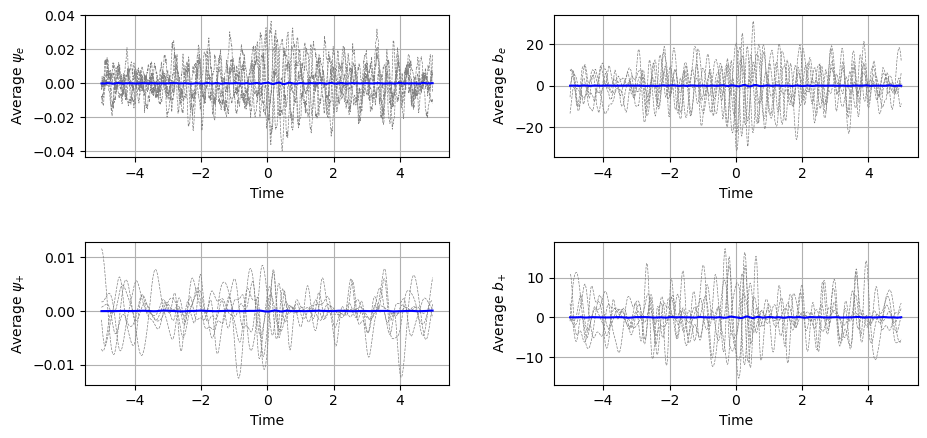

In [36]:
time_array = np.arange(-window_size/10, window_size/10) * dt * 10

fig, axs = plt.subplots(2, 2, figsize=(10, 5))

for i in range(5):
    axs[0, 0].plot(time_array, df['psi_e'][i], linewidth=0.5, linestyle='--', color='gray')
axs[0, 0].plot(time_array, average_psi_e, label='Average', linewidth=1.5, color='blue')
axs[0, 0].set_ylabel(r'$\text{Average } \psi_{e}$')
axs[0, 0].set_xlabel('Time')
axs[0, 0].grid()


for i in range(5):
    axs[0, 1].plot(time_array, df['b_e'][i], linewidth=0.5, linestyle='--', color='gray')
axs[0, 1].plot(time_array, average_b_e, label='Average', linewidth=1.5, color='blue')
axs[0, 1].set_ylabel(r'$\text{Average } b_{e}$')
axs[0, 1].set_xlabel('Time')
axs[0, 1].grid()

for i in range(5):
    axs[1, 0].plot(time_array, df['psi_plus'][i],linewidth=0.5, linestyle='--', color='gray') 
axs[1, 0].plot(time_array, average_psi_plus, label='Average', linewidth=1.5, color='blue')
axs[1, 0].set_ylabel(r'$\text{Average } \psi_{+}$')
axs[1, 0].set_xlabel('Time')
axs[1, 0].grid()

for i in range(5):
    axs[1, 1].plot(time_array, df['b_plus'][i], linewidth=0.5, linestyle='--', color='gray')
axs[1, 1].plot(time_array, average_b_plus, label='Average', linewidth=1.5, color='blue')
axs[1, 1].set_ylabel(r'$\text{Average } b_{+}$')
axs[1, 1].set_xlabel('Time')
axs[1, 1].grid()

plt.subplots_adjust(wspace=0.3, hspace=0.3, top=1.85)

plt.tight_layout(pad = 3)

plt.show()


U and R values

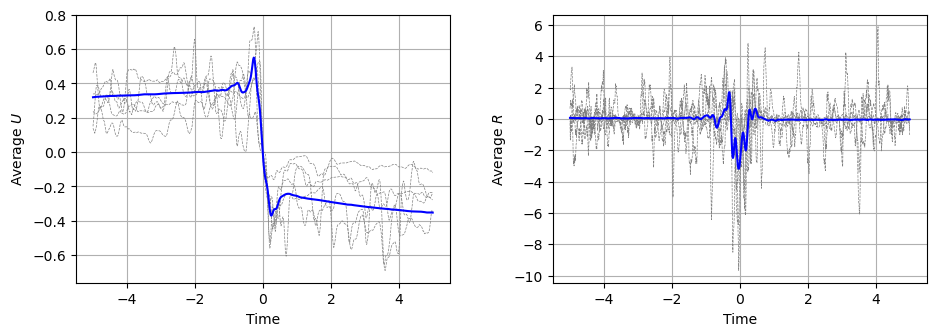

In [37]:
# Define the time array
time_array = np.arange(-window_size / 10, window_size / 10) * dt * 10

# Create a 1x2 subplot layout
fig, axs = plt.subplots(1, 2, figsize=(10, 4))

# Plot U
for i in range(5):
    axs[0].plot(time_array, df['u_list'][i], linewidth=0.5, linestyle='--', color='gray')
axs[0].plot(time_array, average_U, label='Average', linewidth=1.5, color='blue')
axs[0].set_ylabel(r'$\text{Average } U$')
axs[0].set_xlabel('Time')
axs[0].grid()

# Plot R
for i in range(5):
    axs[1].plot(time_array, df['r_list'][i], linewidth=0.5, linestyle='--', color='gray')
axs[1].plot(time_array, average_R, label='Average', linewidth=1.5, color='blue')
axs[1].set_ylabel(r'$\text{Average } R$')
axs[1].set_xlabel('Time')
axs[1].grid()

# Adjust layout
plt.tight_layout(pad=3)
plt.show()


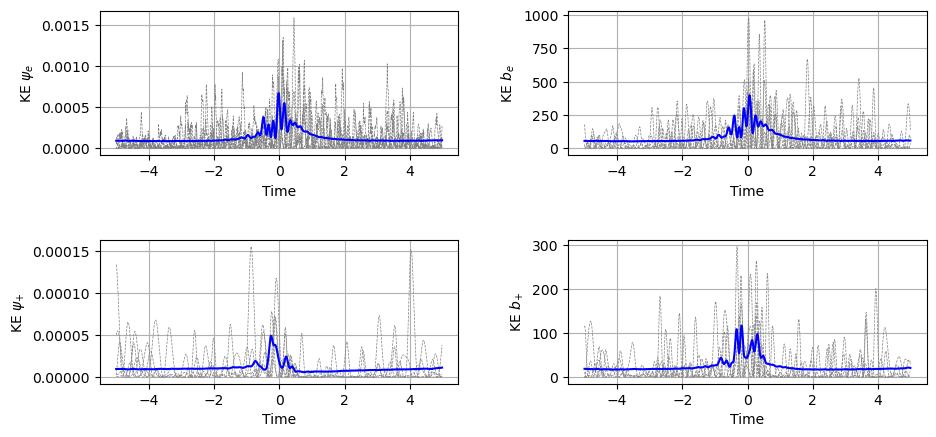

In [38]:
import matplotlib.pyplot as plt
import numpy as np

# Define the time array
time_array = np.arange(-window_size / 10, window_size / 10) * dt * 10

# Create a 2x2 subplot layout
fig, axs = plt.subplots(2, 2, figsize=(10, 5))

# KE psi_e
for i in range(5):
    axs[0, 0].plot(time_array, df['k_e_psi_e_list'][i], linewidth=0.5, linestyle='--', color='gray')
axs[0, 0].plot(time_array, average_k_e_psi_e_list, label='Average', linewidth=1.5, color='blue')
axs[0, 0].set_ylabel(r'$\text{KE } \psi_{e}$')
axs[0, 0].set_xlabel('Time')
axs[0, 0].grid()

# KE b_e
for i in range(5):
    axs[0, 1].plot(time_array, df['k_e_b_e_list'][i], linewidth=0.5, linestyle='--', color='gray')
axs[0, 1].plot(time_array, average_k_e_b_e_list, label='Average', linewidth=1.5, color='blue')
axs[0, 1].set_ylabel(r'$\text{KE } b_{e}$')
axs[0, 1].set_xlabel('Time')
axs[0, 1].grid()

# KE psi_plus
for i in range(5):
    axs[1, 0].plot(time_array, df['k_e_psi_plus_list'][i], linewidth=0.5, linestyle='--', color='gray')
axs[1, 0].plot(time_array, average_k_e_psi_plus_list, label='Average', linewidth=1.5, color='blue')
axs[1, 0].set_ylabel(r'$\text{KE } \psi_{+}$')
axs[1, 0].set_xlabel('Time')
axs[1, 0].grid()

# KE b_plus
for i in range(5):
    axs[1, 1].plot(time_array, df['k_e_b_plus_list'][i], linewidth=0.5, linestyle='--', color='gray')
axs[1, 1].plot(time_array, average_k_e_b_plus_list, label='Average', linewidth=1.5, color='blue')
axs[1, 1].set_ylabel(r'$\text{KE } b_{+}$')
axs[1, 1].set_xlabel('Time')
axs[1, 1].grid()

# Layout adjustments
plt.tight_layout(pad=3)
plt.show()



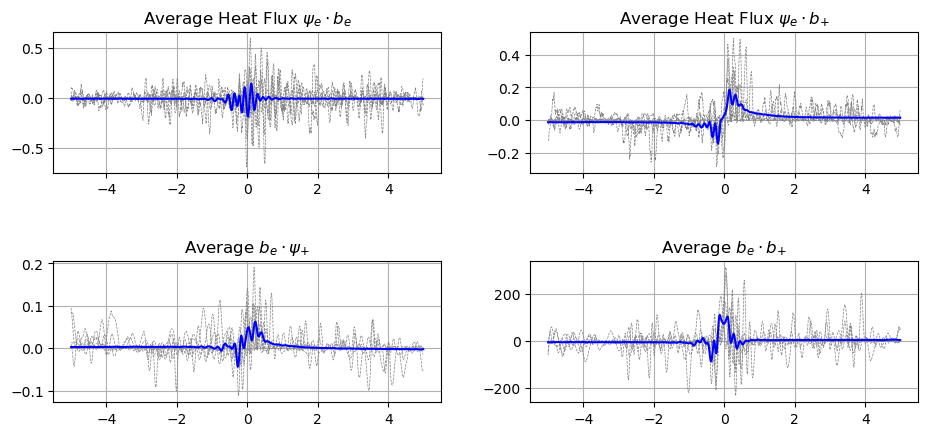

In [39]:
import matplotlib.pyplot as plt
import numpy as np

# Define the time array
time_array = np.arange(-window_size / 10, window_size / 10) * dt * 10

# Create a 2x2 subplot layout
fig, axs = plt.subplots(2, 2, figsize=(10, 5))

for i in range(5):
    axs[0, 0].plot(time_array, df['heat_flux_psi_e_b_e_list'][i], linewidth=0.5, linestyle='--', color='gray')
axs[0, 0].plot(time_array, average_heat_flux_psi_e_b_e_list, label='Average', linewidth=1.5, color='blue')
axs[0, 0].set_title(r'Average Heat Flux $ \psi_{e} \cdot b_{e} $')
axs[0, 0].grid()

for i in range(5):
    axs[0, 1].plot(time_array, df['heat_flux_psi_e_b_plus_list'][i], linewidth=0.5, linestyle='--', color='gray')
axs[0, 1].plot(time_array, average_heat_flux_psi_e_b_plus_list, label='Average', linewidth=1.5, color='blue')
axs[0, 1].set_title(r'Average Heat Flux $ \psi_{e} \cdot b_{+} $')
axs[0, 1].grid()

for i in range(5):
    axs[1, 0].plot(time_array, df['b_e_psi_plus_list'][i], linewidth=0.5, linestyle='--', color='gray')
axs[1, 0].plot(time_array, average_b_e_psi_plus_list, label='Average', linewidth=1.5, color='blue')
axs[1, 0].set_title(r'Average $ b_{e} \cdot \psi_{+} $')
axs[1, 0].grid()

for i in range(5):
    axs[1, 1].plot(time_array, df['b_e_b_plus_list'][i], linewidth=0.5, linestyle='--', color='gray')
axs[1, 1].plot(time_array, average_b_e_b_plus_list, label='Average', linewidth=1.5, color='blue')
axs[1, 1].set_title(r'Average $ b_{e} \cdot b_{+} $')
axs[1, 1].grid()

# Layout adjustments
plt.tight_layout(pad=3)
plt.show()


In [40]:

# for i in range(5):
#     axs[7, 0].plot(time_array, df['psi_plus_b_plus_list'][i], linewidth=0.5, linestyle='--', color='gray')
# axs[7, 0].plot(time_array, average_psi_plus_b_plus_list, label='Average', linewidth=1.5, color='blue')
# axs[7, 0].set_title(f'Average psi_plus * b_plus')
# axs[7, 0].grid()


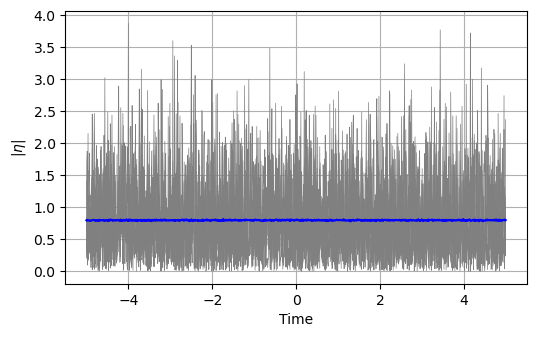

In [41]:

average_eta = [[i for i in sublist] for sublist in average_eta]

time_array = np.arange(-window_size / 10, window_size / 10) * dt * 10

# Create a single subplot
fig, ax = plt.subplots(figsize=(6, 4))

# Plot absolute value of eta_list
for i in range(5):
    ax.plot(time_array, [val[0] for val in np.abs(df['eta_list'][i])], linewidth=0.5, linestyle='-', color='gray')
ax.plot(time_array, [val[0] for val in average_eta], label='Average', linewidth=1.5, color='blue')

# Labels and styling
ax.set_ylabel(r'$|\eta|$')
ax.set_xlabel('Time')
ax.grid()

# Adjust layout
plt.tight_layout(pad=3)
plt.show()

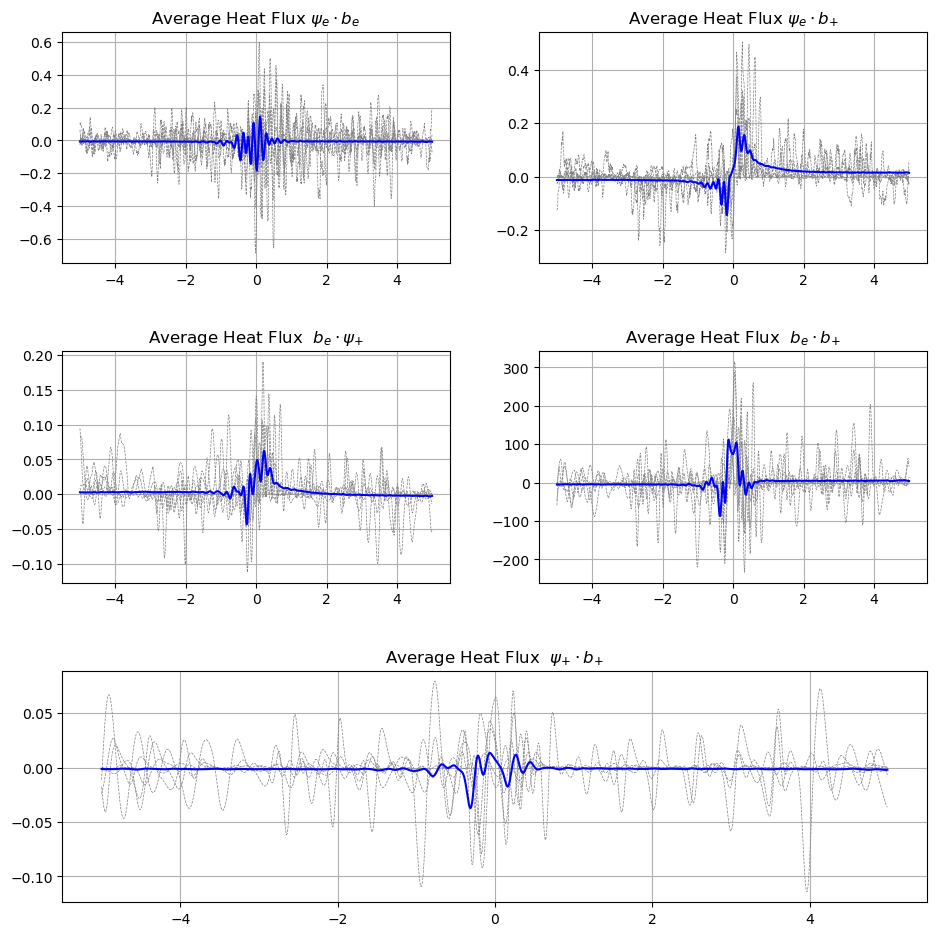

In [42]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

fig = plt.figure(figsize=(10, 10))
gs = gridspec.GridSpec(3, 2, figure=fig)

# Top 4 plots
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 0])
ax4 = fig.add_subplot(gs[1, 1])
# Centered plot in third row
ax5 = fig.add_subplot(gs[2, :])  # spans both columns

# Plot 1
for i in range(5):
    ax1.plot(time_array, df['heat_flux_psi_e_b_e_list'][i], linewidth=0.5, linestyle='--', color='gray')
ax1.plot(time_array, average_heat_flux_psi_e_b_e_list, linewidth=1.5, color='blue')
ax1.set_title(r'Average Heat Flux $ \psi_{e} \cdot b_{e} $')
ax1.grid()

# Plot 2
for i in range(5):
    ax2.plot(time_array, df['heat_flux_psi_e_b_plus_list'][i], linewidth=0.5, linestyle='--', color='gray')
ax2.plot(time_array, average_heat_flux_psi_e_b_plus_list, linewidth=1.5, color='blue')
ax2.set_title(r'Average Heat Flux $ \psi_{e} \cdot b_{+} $')
ax2.grid()

# Plot 3
for i in range(5):
    ax3.plot(time_array, df['b_e_psi_plus_list'][i], linewidth=0.5, linestyle='--', color='gray')
ax3.plot(time_array, average_b_e_psi_plus_list, linewidth=1.5, color='blue')
ax3.set_title(r'Average Heat Flux  $ b_{e} \cdot \psi_{+} $')
ax3.grid()

# Plot 4
for i in range(5):
    ax4.plot(time_array, df['b_e_b_plus_list'][i], linewidth=0.5, linestyle='--', color='gray')
ax4.plot(time_array, average_b_e_b_plus_list, linewidth=1.5, color='blue')
ax4.set_title(r'Average Heat Flux  $ b_{e} \cdot b_{+} $')
ax4.grid()

# Plot 5 (centered)
for i in range(5):
    ax5.plot(time_array, df['psi_plus_b_plus_list'][i], linewidth=0.5, linestyle='--', color='gray')
ax5.plot(time_array, average_psi_plus_b_plus_list, linewidth=1.5, color='blue')
ax5.set_title(r'Average Heat Flux  $ \psi_{+} \cdot b_{+} $')
ax5.grid()

plt.tight_layout(pad=3)
plt.show()


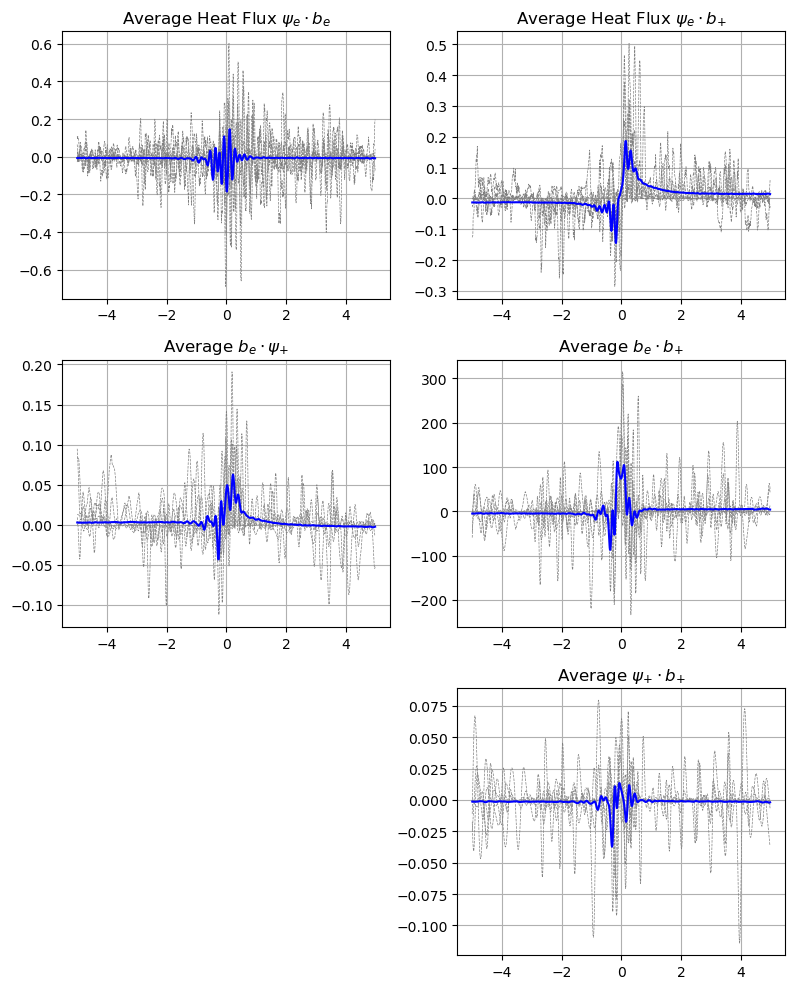

In [43]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

fig = plt.figure(figsize=(12, 10))
gs = gridspec.GridSpec(3, 3, figure=fig)  # 3 rows, 3 columns

# Top 4 plots (spread over two rows)
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 0])
ax4 = fig.add_subplot(gs[1, 1])

# Centered 5th plot in the middle column of bottom row
ax5 = fig.add_subplot(gs[2, 1])  # row 2, column 1 (center)

# Plot each
for i in range(5):
    ax1.plot(time_array, df['heat_flux_psi_e_b_e_list'][i], linewidth=0.5, linestyle='--', color='gray')
ax1.plot(time_array, average_heat_flux_psi_e_b_e_list, linewidth=1.5, color='blue')
ax1.set_title(r'Average Heat Flux $ \psi_{e} \cdot b_{e} $')
ax1.grid()

for i in range(5):
    ax2.plot(time_array, df['heat_flux_psi_e_b_plus_list'][i], linewidth=0.5, linestyle='--', color='gray')
ax2.plot(time_array, average_heat_flux_psi_e_b_plus_list, linewidth=1.5, color='blue')
ax2.set_title(r'Average Heat Flux $ \psi_{e} \cdot b_{+} $')
ax2.grid()

for i in range(5):
    ax3.plot(time_array, df['b_e_psi_plus_list'][i], linewidth=0.5, linestyle='--', color='gray')
ax3.plot(time_array, average_b_e_psi_plus_list, linewidth=1.5, color='blue')
ax3.set_title(r'Average $ b_{e} \cdot \psi_{+} $')
ax3.grid()

for i in range(5):
    ax4.plot(time_array, df['b_e_b_plus_list'][i], linewidth=0.5, linestyle='--', color='gray')
ax4.plot(time_array, average_b_e_b_plus_list, linewidth=1.5, color='blue')
ax4.set_title(r'Average $ b_{e} \cdot b_{+} $')
ax4.grid()

for i in range(5):
    ax5.plot(time_array, df['psi_plus_b_plus_list'][i], linewidth=0.5, linestyle='--', color='gray')
ax5.plot(time_array, average_psi_plus_b_plus_list, linewidth=1.5, color='blue')
ax5.set_title(r'Average $ \psi_{+} \cdot b_{+} $')
ax5.grid()

plt.tight_layout()
plt.show()


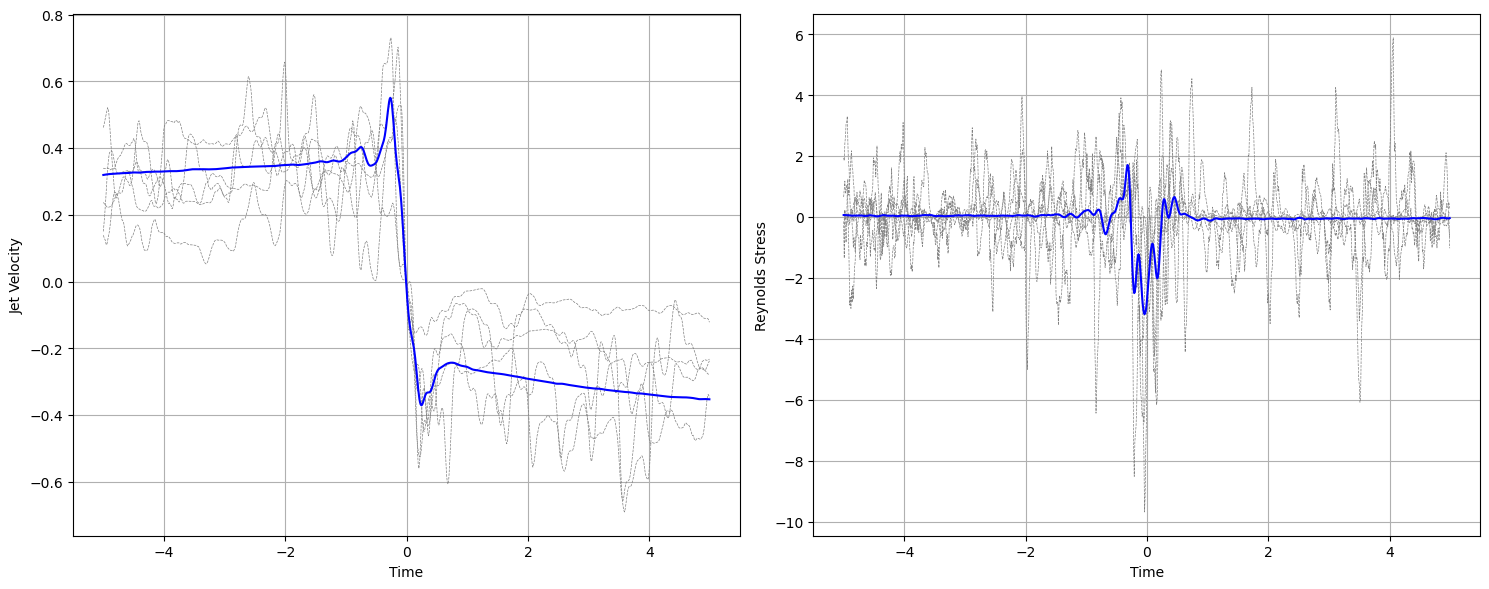

In [44]:
time_array = np.arange(-window_size/10, window_size/10) * dt * 10

fig, axs = plt.subplots(1, 2, figsize=(15, 6))

# for i in range(5):
#     axs[0, 0].plot(time_array, df['psi_e'][i], linewidth=0.5, linestyle='--', color='gray')
# axs[0, 0].plot(time_array, average_psi_e, label='Average', linewidth=1.5, color='blue')
# axs[0, 0].set_title(f'Average psi_e')
# axs[0, 0].grid()


# for i in range(5):
#     axs[0, 1].plot(time_array, df['b_e'][i], linewidth=0.5, linestyle='--', color='gray')
# axs[0, 1].plot(time_array, average_b_e, label='Average', linewidth=1.5, color='blue')
# axs[0, 1].set_title(f'Average b_e')
# axs[0, 1].grid()

# for i in range(5):
#     axs[1, 0].plot(time_array, df['psi_plus'][i],linewidth=0.5, linestyle='--', color='gray') 
# axs[1, 0].plot(time_array, average_psi_plus, label='Average', linewidth=1.5, color='blue')
# axs[1, 0].set_title(f'Average psi_plus')
# axs[1, 0].grid()

# for i in range(5):
#     axs[1, 1].plot(time_array, df['b_plus'][i], linewidth=0.5, linestyle='--', color='gray')
# axs[1, 1].plot(time_array, average_b_plus, label='Average', linewidth=1.5, color='blue')
# axs[1, 1].set_title(f'Average b_plus')
# axs[1, 1].grid()

for i in range(5):
    axs[0].plot(time_array, df['u_list'][i], linewidth=0.5, linestyle='--', color='gray')
axs[0].plot(time_array, average_U, label='Average', linewidth=1.5, color='blue')
# axs[0].set_title(f'Average U')
axs[0].set_xlabel('Time')
axs[0].set_ylabel('Jet Velocity')
axs[0].grid()

for i in range(5):
    axs[1].plot(time_array, df['r_list'][i], linewidth=0.5, linestyle='--', color='gray')
axs[1].plot(time_array, average_R, label='Average', linewidth=1.5, color='blue')
# axs[1].set_title(f'Average R')
axs[1].set_xlabel('Time')
axs[1].set_ylabel('Reynolds Stress')
axs[1].grid()

# for i in range(5):
#     axs[3, 0].plot(time_array, df['k_e_psi_e_list'][i], linewidth=0.5, linestyle='--', color='gray')
# axs[3, 0].plot(time_array, average_k_e_psi_e_list, label='Average', linewidth=1.5, color='blue')
# axs[3, 0].set_title(f'Average KE psi_e')
# axs[3, 0].grid()

# for i in range(5):
#     axs[3, 1].plot(time_array, df['k_e_b_e_list'][i], linewidth=0.5, linestyle='--', color='gray')
# axs[3, 1].plot(time_array, average_k_e_b_e_list, label='Average', linewidth=1.5, color='blue')
# axs[3, 1].set_title(f'Average KE b_e')
# axs[3, 1].grid()

# for i in range(5):
#     axs[4, 0].plot(time_array, df['k_e_psi_plus_list'][i], linewidth=0.5, linestyle='--', color='gray')
# axs[4, 0].plot(time_array, average_k_e_psi_plus_list, label='Average', linewidth=1.5, color='blue')
# axs[4, 0].set_title(f'Average KE psi_plus')
# axs[4, 0].grid()

# for i in range(5):
#     axs[4, 1].plot(time_array, df['k_e_b_plus_list'][i], linewidth=0.5, linestyle='--', color='gray')
# axs[4, 1].plot(time_array, average_k_e_b_plus_list, label='Average', linewidth=1.5, color='blue')
# axs[4, 1].set_title(f'Average KE b_plus')
# axs[4, 1].grid()

# for i in range(5):
#     axs[5, 0].plot(time_array, df['heat_flux_psi_e_b_e_list'][i], linewidth=0.5, linestyle='--', color='gray')
# axs[5, 0].plot(time_array, average_heat_flux_psi_e_b_e_list, label='Average', linewidth=1.5, color='blue')
# axs[5, 0].set_title(f'Average Heat Flux psi_e * b_e')
# axs[5, 0].grid()

# for i in range(5):
#     axs[5, 1].plot(time_array, df['heat_flux_psi_e_b_plus_list'][i], linewidth=0.5, linestyle='--', color='gray')
# axs[5, 1].plot(time_array, average_heat_flux_psi_e_b_plus_list, label='Average', linewidth=1.5, color='blue')
# axs[5, 1].set_title(f'Average Heat Flux psi_e * b_plus')
# axs[5, 1].grid()

# for i in range(5):
#     axs[6, 0].plot(time_array, df['b_e_psi_plus_list'][i], linewidth=0.5, linestyle='--', color='gray')
# axs[6, 0].plot(time_array, average_b_e_psi_plus_list, label='Average', linewidth=1.5, color='blue')
# axs[6, 0].set_title(f'Average b_e * psi_plus')
# axs[6, 0].grid()

# for i in range(5):
#     axs[6, 1].plot(time_array, df['b_e_b_plus_list'][i], linewidth=0.5, linestyle='--', color='gray')
# axs[6, 1].plot(time_array, average_b_e_b_plus_list, label='Average', linewidth=1.5, color='blue')
# axs[6, 1].set_title(f'Average b_e * b_plus')
# axs[6, 1].grid()

# for i in range(5):
#     axs[7, 0].plot(time_array, df['psi_plus_b_plus_list'][i], linewidth=0.5, linestyle='--', color='gray')
# axs[7, 0].plot(time_array, average_psi_plus_b_plus_list, label='Average', linewidth=1.5, color='blue')
# axs[7, 0].set_title(f'Average psi_plus * b_plus')
# axs[7, 0].grid()

# average_eta = [[abs(i) for i in sublist] for sublist in average_eta]

# for i in range(5): #Check if the average eta is the same using randn 
#     axs[7, 1].plot(time_array, [abs(i[0]) for i in df['eta_list'][i]], linewidth=0.5, linestyle='-', label=f'eta_list {i}', color = 'gray')
# axs[7, 1].plot(time_array, [abs(i[0]) for i in average_eta], label='Average', linewidth=1.5, color='blue')
# axs[7, 1].set_title('Average eta (Absolute Value)')
# axs[7, 1].grid()


# plt.suptitle(f'Composite Analysis for Eps: {epsilon} and N0Sq: {N_0_squared} (Total count: {len(list(df['b_e']))})', fontsize=16)
# plt.subplots_adjust(wspace=0.3, hspace=0.3, top=1.85)

plt.tight_layout()

plt.show()

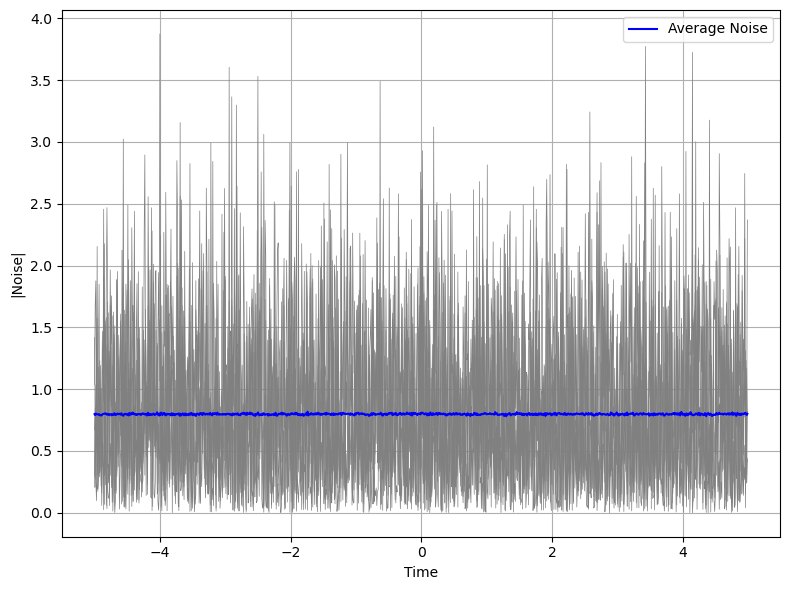

In [45]:
time_array = np.arange(-window_size/10, window_size/10) * dt * 10

fig, axs = plt.subplots(1, 1, figsize=(8,6))

# for i in range(5):
#     axs[0, 0].plot(time_array, df['psi_e'][i], linewidth=0.5, linestyle='--', color='gray')
# axs[0, 0].plot(time_array, average_psi_e, label='Average', linewidth=1.5, color='blue')
# axs[0, 0].set_title(f'Average psi_e')
# axs[0, 0].grid()


# for i in range(5):
#     axs[0, 1].plot(time_array, df['b_e'][i], linewidth=0.5, linestyle='--', color='gray')
# axs[0, 1].plot(time_array, average_b_e, label='Average', linewidth=1.5, color='blue')
# axs[0, 1].set_title(f'Average b_e')
# axs[0, 1].grid()

# for i in range(5):
#     axs[1, 0].plot(time_array, df['psi_plus'][i],linewidth=0.5, linestyle='--', color='gray') 
# axs[1, 0].plot(time_array, average_psi_plus, label='Average', linewidth=1.5, color='blue')
# axs[1, 0].set_title(f'Average psi_plus')
# axs[1, 0].grid()

# for i in range(5):
#     axs[1, 1].plot(time_array, df['b_plus'][i], linewidth=0.5, linestyle='--', color='gray')
# axs[1, 1].plot(time_array, average_b_plus, label='Average', linewidth=1.5, color='blue')
# axs[1, 1].set_title(f'Average b_plus')
# axs[1, 1].grid()

# for i in range(5):
#     axs.plot(time_array, df['u_list'][i], linewidth=0.5, linestyle='--', color='gray')
# axs.plot(time_array, average_U, label='Average', linewidth=1.5, color='blue')
# # axs[0].set_title(f'Average U')
# axs.set_xlabel('Time')
# axs.set_ylabel('Jet Velocity')
# axs.grid()



# for i in range(5):
#     axs[3, 0].plot(time_array, df['k_e_psi_e_list'][i], linewidth=0.5, linestyle='--', color='gray')
# axs[3, 0].plot(time_array, average_k_e_psi_e_list, label='Average', linewidth=1.5, color='blue')
# axs[3, 0].set_title(f'Average KE psi_e')
# axs[3, 0].grid()

# for i in range(5):
#     axs[3, 1].plot(time_array, df['k_e_b_e_list'][i], linewidth=0.5, linestyle='--', color='gray')
# axs[3, 1].plot(time_array, average_k_e_b_e_list, label='Average', linewidth=1.5, color='blue')
# axs[3, 1].set_title(f'Average KE b_e')
# axs[3, 1].grid()

# for i in range(5):
#     axs[4, 0].plot(time_array, df['k_e_psi_plus_list'][i], linewidth=0.5, linestyle='--', color='gray')
# axs[4, 0].plot(time_array, average_k_e_psi_plus_list, label='Average', linewidth=1.5, color='blue')
# axs[4, 0].set_title(f'Average KE psi_plus')
# axs[4, 0].grid()

# for i in range(5):
#     axs[4, 1].plot(time_array, df['k_e_b_plus_list'][i], linewidth=0.5, linestyle='--', color='gray')
# axs[4, 1].plot(time_array, average_k_e_b_plus_list, label='Average', linewidth=1.5, color='blue')
# axs[4, 1].set_title(f'Average KE b_plus')
# axs[4, 1].grid()

# for i in range(5):
#     axs[5, 0].plot(time_array, df['heat_flux_psi_e_b_e_list'][i], linewidth=0.5, linestyle='--', color='gray')
# axs[5, 0].plot(time_array, average_heat_flux_psi_e_b_e_list, label='Average', linewidth=1.5, color='blue')
# axs[5, 0].set_title(f'Average Heat Flux psi_e * b_e')
# axs[5, 0].grid()

# for i in range(5):
#     axs[5, 1].plot(time_array, df['heat_flux_psi_e_b_plus_list'][i], linewidth=0.5, linestyle='--', color='gray')
# axs[5, 1].plot(time_array, average_heat_flux_psi_e_b_plus_list, label='Average', linewidth=1.5, color='blue')
# axs[5, 1].set_title(f'Average Heat Flux psi_e * b_plus')
# axs[5, 1].grid()

# for i in range(5):
#     axs[6, 0].plot(time_array, df['b_e_psi_plus_list'][i], linewidth=0.5, linestyle='--', color='gray')
# axs[6, 0].plot(time_array, average_b_e_psi_plus_list, label='Average', linewidth=1.5, color='blue')
# axs[6, 0].set_title(f'Average b_e * psi_plus')
# axs[6, 0].grid()

# for i in range(5):
#     axs[6, 1].plot(time_array, df['b_e_b_plus_list'][i], linewidth=0.5, linestyle='--', color='gray')
# axs[6, 1].plot(time_array, average_b_e_b_plus_list, label='Average', linewidth=1.5, color='blue')
# axs[6, 1].set_title(f'Average b_e * b_plus')
# axs[6, 1].grid()

# for i in range(5):
#     axs[7, 0].plot(time_array, df['psi_plus_b_plus_list'][i], linewidth=0.5, linestyle='--', color='gray')
# axs[7, 0].plot(time_array, average_psi_plus_b_plus_list, label='Average', linewidth=1.5, color='blue')
# axs[7, 0].set_title(f'Average psi_plus * b_plus')
# axs[7, 0].grid()

average_eta = [[abs(i) for i in sublist] for sublist in average_eta]

for i in range(5): #Check if the average eta is the same using randn 
    axs.plot(time_array, [abs(i[0]) for i in df['eta_list'][i]], linewidth=0.5, linestyle='-', color = 'gray')
axs.plot(time_array, [abs(i[0]) for i in average_eta], label='Average Noise', linewidth=1.5, color='blue')
# axs.set_title('Average eta (Absolute Value)')
axs.set_xlabel('Time')
axs.set_ylabel('|Noise|')
axs.grid()


# plt.suptitle(f'Composite Analysis for Eps: {epsilon} and N0Sq: {N_0_squared} (Total count: {len(list(df['b_e']))})', fontsize=16)
# plt.subplots_adjust(wspace=0.3, hspace=0.3, top=1.85)
plt.legend()
plt.tight_layout()

plt.show()